# ICOS Obspack zarr — interactive station/gas viewer

Pick a station trigram → height (m a.g.l.) → gas, then plot the time series.

Each zarr group is named `{TRIGRAM}{HEIGHT}` (e.g. `HTM150`); the group can
contain `co2`, `ch4`, `n2o`, and/or `co` as separate time-aligned variables.

In [4]:
#!pip install folium
import pathlib
import re
from collections import defaultdict

import xarray as xr
import zarr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display, clear_output

STORE = pathlib.Path("icos-obspack.zarr")
GASES = ("co2", "ch4", "n2o", "co")
GAS_UNITS = {"co2": "ppm", "ch4": "ppb", "n2o": "ppb", "co": "ppb"}

_SID_RE = re.compile(r"^([A-Z]{3})(\d+)$")

z = zarr.open_group(str(STORE), mode="r")

# Build {trigram: {height: station_id}} index from group names
_index: dict[str, dict[int, str]] = defaultdict(dict)
for sid in sorted(z.group_keys()):
    m = _SID_RE.match(sid)
    if not m:
        continue
    _index[m.group(1)][int(m.group(2))] = sid

trigrams = sorted(_index)

def gases_in(sid: str) -> list[str]:
    """Return the gases present in a station group, in canonical order."""
    grp = z[sid]
    arrs = set(grp.array_keys())
    return [g for g in GASES if g in arrs]

print(f"Store      : {STORE}")
print(f"Trigrams   : {len(trigrams)}")
print(f"Stations   : {sum(len(h) for h in _index.values())}")

Store      : icos-obspack.zarr
Trigrams   : 40
Stations   : 100


In [5]:
# ── Widgets ───────────────────────────────────────────────────────────────────

w_trigram = widgets.Dropdown(
    options=trigrams,
    value=trigrams[0] if trigrams else None,
    description="Station:",
    layout=widgets.Layout(width="180px"),
)

w_height = widgets.Dropdown(
    options=[],
    description="Height:",
    layout=widgets.Layout(width="180px"),
)

w_gas = widgets.Dropdown(
    options=[],
    description="Gas:",
    layout=widgets.Layout(width="160px"),
)

w_btn = widgets.Button(
    description="Plot",
    button_style="primary",
    layout=widgets.Layout(width="100px"),
)

w_info = widgets.HTML(value="")
out    = widgets.Output()

# ── Cascade: trigram → height → gas ───────────────────────────────────────────

def _on_trigram_change(change):
    trig = change["new"]
    heights = sorted(_index[trig])
    w_height.options = [(f"{h} m", h) for h in heights]
    w_height.value   = heights[0] if heights else None

def _on_height_change(change):
    if w_trigram.value is None or change["new"] is None:
        w_gas.options = []
        return
    sid = _index[w_trigram.value][change["new"]]
    gases = gases_in(sid)
    w_gas.options = [(g.upper(), g) for g in gases]
    w_gas.value   = gases[0] if gases else None
    # Show site metadata
    attrs = dict(z[sid].attrs)
    site = attrs.get("site_name", "")
    cc   = attrs.get("country_code", attrs.get("site_country", ""))
    lat  = attrs.get("site_latitude", attrs.get("latitude", "?"))
    lon  = attrs.get("site_longitude", attrs.get("longitude", "?"))
    pi   = attrs.get("current_pi", "")
    bits = [f"<b>{sid}</b>", site, cc and f"({cc})", f"{lat}, {lon}"]
    if pi:
        bits.append(f"PI: {pi}")
    w_info.value = "<small>" + " \u2014 ".join(b for b in bits if b) + "</small>"

w_trigram.observe(_on_trigram_change, names="value")
w_height.observe(_on_height_change,  names="value")
_on_trigram_change({"new": w_trigram.value})
_on_height_change({"new": w_height.value})

# ── Plot ──────────────────────────────────────────────────────────────────────

def _on_plot(btn):
    if w_trigram.value is None or w_height.value is None or w_gas.value is None:
        return
    sid = _index[w_trigram.value][w_height.value]
    gas = w_gas.value

    with out:
        clear_output(wait=True)
        ds = xr.open_zarr(str(STORE), group=sid, consolidated=False)
        if gas not in ds:
            print(f"{gas!r} not found in {sid}")
            return

        da     = ds[gas]
        time   = ds[f"time_{gas}"].values
        units  = da.attrs.get("units", GAS_UNITS.get(gas, ""))
        cal    = ds.attrs.get(f"{gas}_calibration_scale", "")
        site   = ds.attrs.get("site_name", "")

        title = f"{sid} ({site}) \u2014 {gas.upper()}"
        if cal:
            title += f"  [scale: {cal}]"

        print(f"{gas.upper()} samples: {len(time):,}  range: {str(time[0])[:10]} \u2192 {str(time[-1])[:10]}")

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(time, da.values, lw=0.5, color="tab:blue")
        ax.set_ylabel(f"{gas.upper()}\n({units})")
        ax.set_title(title)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()

w_btn.on_click(_on_plot)

display(
    widgets.HBox([w_trigram, w_height, w_gas, w_btn]),
    w_info,
    out,
)

HTML(value='<small><b>ARN10</b> — El Arenosillo — (ES) — 37.104, -6.734 — PI: José Adame</small>')

Output()

## Data coverage overview (Gantt)

Each row = one `(station, gas)` pair.  Bars span the start → stop date
recorded in the group `.zattrs` for that gas.  Stations are grouped by
trigram, sorted by maximum height first within each trigram.

In [6]:
# ── Build coverage table from .zattrs ─────────────────────────────────────────

import pandas as pd

GAS_COLOR = {"co2": "#1f77b4", "ch4": "#2ca02c", "n2o": "#d62728", "co": "#ff7f0e"}

def _parse_iso(s: str):
    if not s:
        return None
    try:
        return pd.Timestamp(s)
    except Exception:
        return None

rows = []
for sid in sorted(z.group_keys()):
    m = _SID_RE.match(sid)
    if not m:
        continue
    trigram = m.group(1)
    height  = int(m.group(2))
    grp     = z[sid]
    attrs   = dict(grp.attrs)
    for gas in GASES:
        if gas not in grp:
            continue
        start = _parse_iso(attrs.get(f"{gas}_start_date"))
        stop  = _parse_iso(attrs.get(f"{gas}_stop_date"))
        if start is None or stop is None:
            continue
        rows.append({
            "station_id": sid,
            "trigram":    trigram,
            "height":     height,
            "gas":        gas,
            "start":      start,
            "stop":       stop,
            "duration":   (stop - start).days,
        })

cov = pd.DataFrame(rows)
print(f"{len(cov):,} (station, gas) coverage entries across {cov['station_id'].nunique()} stations")
cov.head()

357 (station, gas) coverage entries across 100 stations


,station_id,trigram,height,gas,start,stop,duration
0,ARN10,ARN,10,co2,2025-04-01 00:00:00+00:00,2026-04-08 23:00:00+00:00,372
1,ARN10,ARN,10,ch4,2025-04-01 00:00:00+00:00,2026-04-09 23:00:00+00:00,373
2,ARN10,ARN,10,co,2025-04-01 00:00:00+00:00,2026-04-10 23:00:00+00:00,374
3,ARN50,ARN,50,co2,2025-04-01 00:00:00+00:00,2026-04-08 23:00:00+00:00,372
4,ARN50,ARN,50,ch4,2025-04-01 00:00:00+00:00,2026-04-09 23:00:00+00:00,373


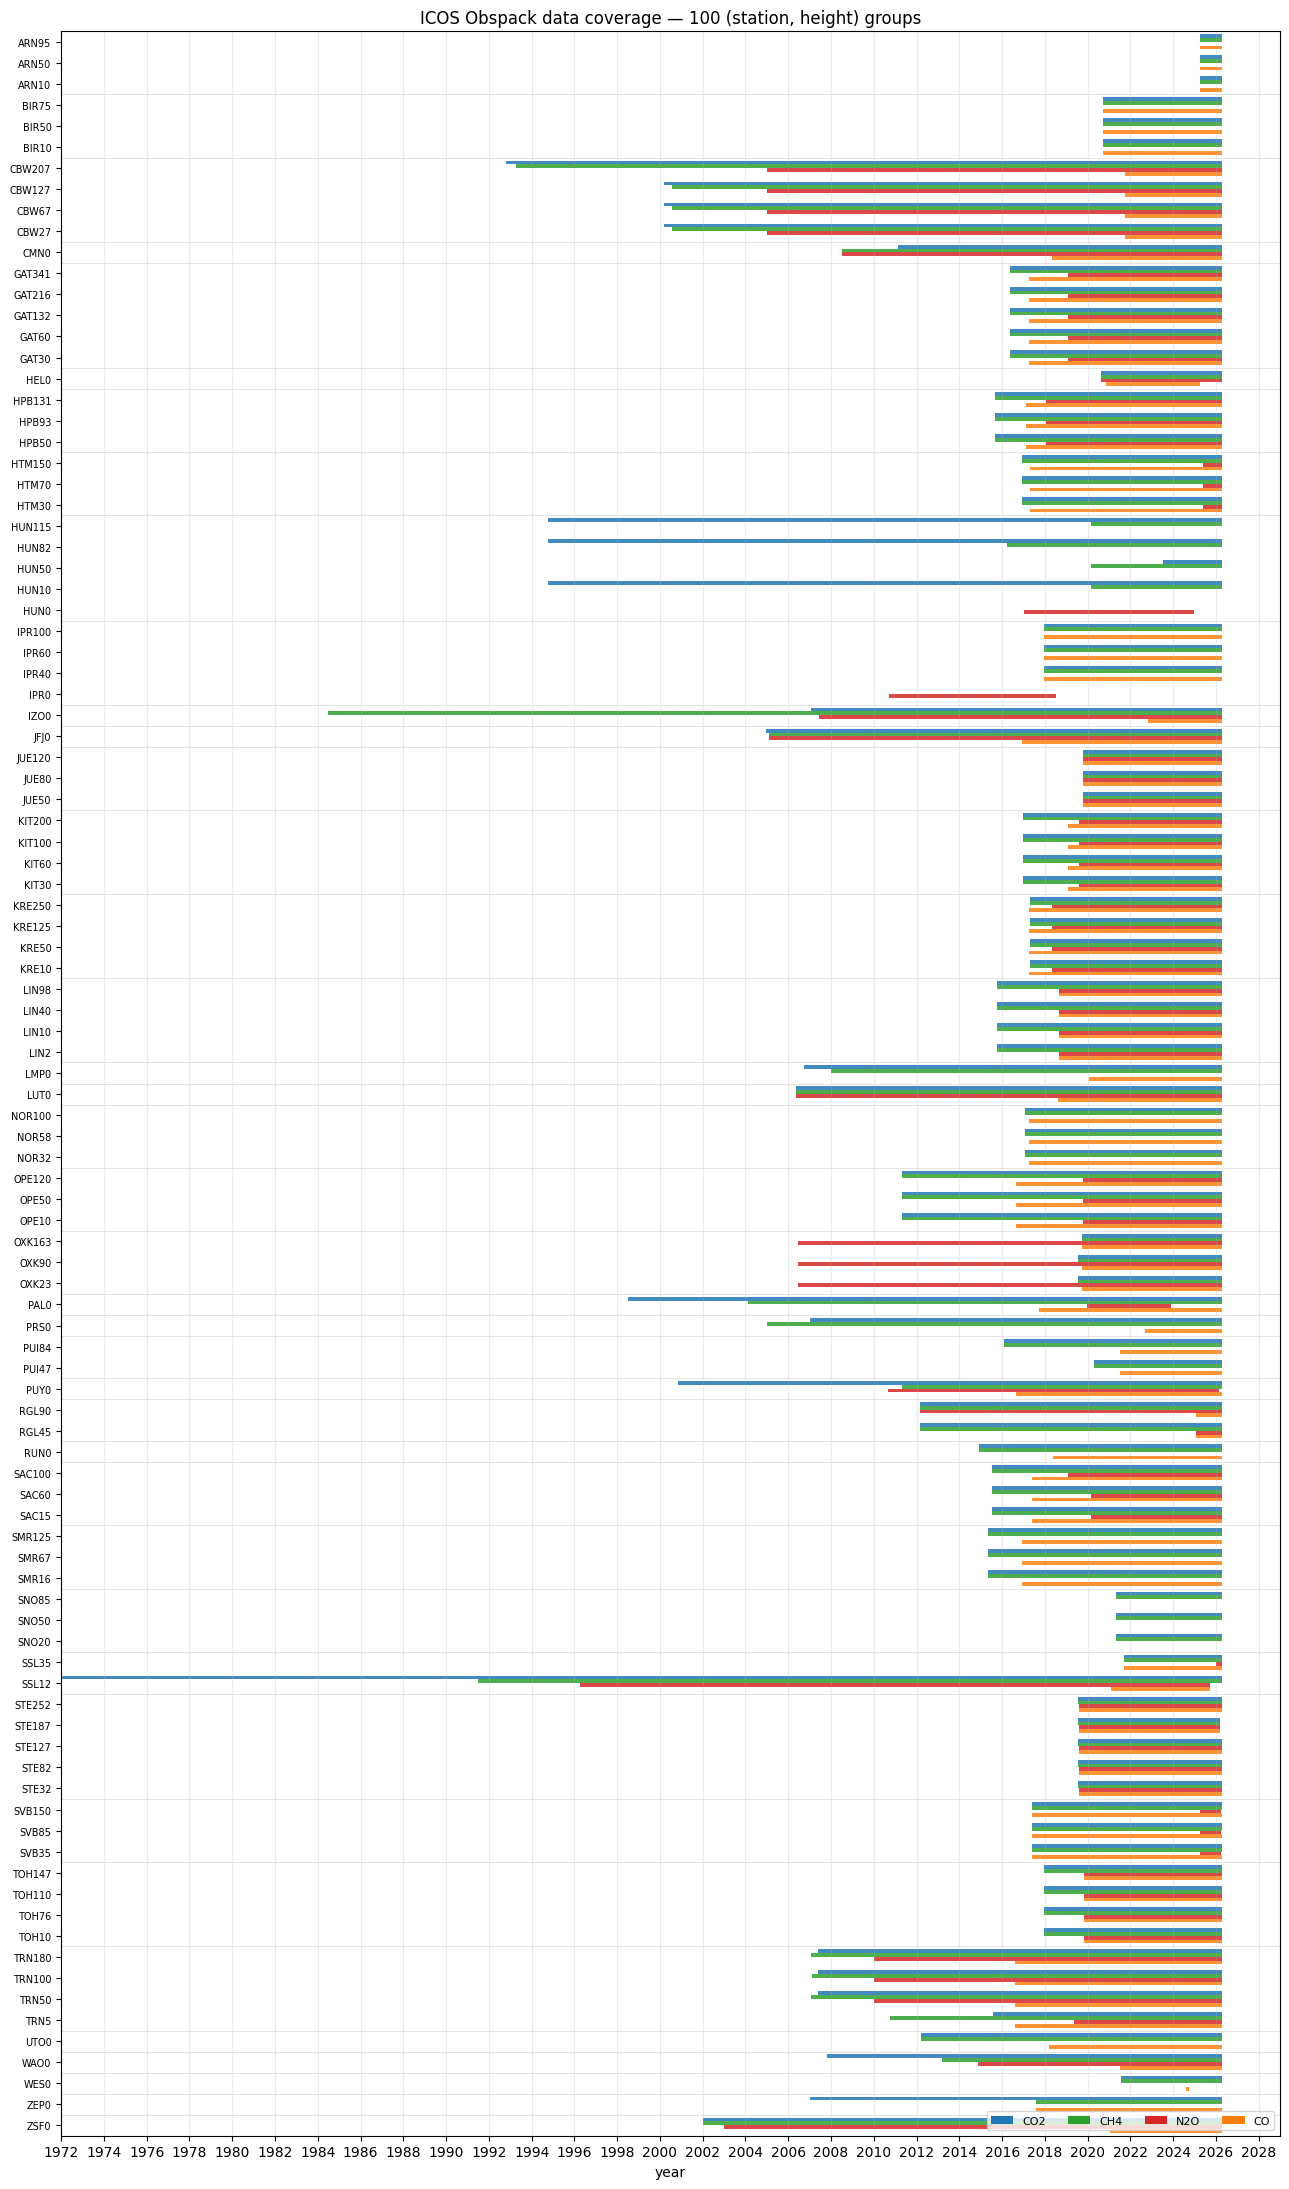

In [7]:
# ── Render the Gantt chart ────────────────────────────────────────────────────

# Order stations: by trigram, then height descending (tallest first within a tower)
station_order = (
    cov[["station_id", "trigram", "height"]]
       .drop_duplicates()
       .sort_values(["trigram", "height"], ascending=[True, False])
       ["station_id"]
       .tolist()
)
y_of = {sid: i for i, sid in enumerate(station_order)}

fig_h = max(6, len(station_order) * 0.22)
fig, ax = plt.subplots(figsize=(13, fig_h))

bar_h        = 0.18
gas_offset   = {"co2": -1.5, "ch4": -0.5, "n2o": 0.5, "co": 1.5}

for _, r in cov.iterrows():
    y = y_of[r["station_id"]] + gas_offset[r["gas"]] * bar_h
    ax.barh(y, (r["stop"] - r["start"]).days, left=r["start"],
            height=bar_h, color=GAS_COLOR[r["gas"]],
            edgecolor="none", alpha=0.85)

# Y axis: station IDs
ax.set_yticks(range(len(station_order)))
ax.set_yticklabels(station_order, fontsize=7)
ax.invert_yaxis()
ax.set_ylim(len(station_order) - 0.5, -0.5)

# Faint grid between trigrams
prev_trig = None
for i, sid in enumerate(station_order):
    trig = _SID_RE.match(sid).group(1)
    if prev_trig is not None and trig != prev_trig:
        ax.axhline(i - 0.5, color="0.85", lw=0.5)
    prev_trig = trig

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel("year")
ax.grid(axis="x", alpha=0.25)
ax.set_title(f"ICOS Obspack data coverage — {len(station_order)} (station, height) groups")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GAS_COLOR[g], label=g.upper()) for g in GASES if g in GAS_COLOR],
          loc="lower right", fontsize=8, ncol=4, frameon=True)

fig.tight_layout()
plt.show()

## Station map

One marker per trigram (a tower with multiple heights collapses to one
location).  Click a marker to see the trigram, full station name, gases
measured, and sampling heights.

In [8]:
import folium

# Aggregate per-trigram: pick lat/lon from any height (all heights share the same
# fixed station coordinates), then collect heights and gases.
sites = []
for trig in trigrams:
    heights = sorted(_index[trig])
    sids = [_index[trig][h] for h in heights]
    # Use the first station's lat/lon (all heights at the same trigram are colocated)
    attrs0 = dict(z[sids[0]].attrs)
    lat = attrs0.get("site_latitude") or attrs0.get("station_lat")
    lon = attrs0.get("site_longitude") or attrs0.get("station_lon")
    if lat is None or lon is None:
        continue
    name    = attrs0.get("site_name", "") or attrs0.get("station_full_name", "")
    country = attrs0.get("country_code", attrs0.get("site_country", ""))
    pi      = attrs0.get("current_pi", "")

    # Union of gases across all heights at this trigram
    gases_seen = set()
    height_rows = []
    for h, sid in zip(heights, sids):
        gs = gases_in(sid)
        gases_seen.update(gs)
        height_rows.append((h, gs))

    sites.append({
        "trigram":     trig,
        "name":        name,
        "country":     country,
        "pi":          pi,
        "lat":         float(lat),
        "lon":         float(lon),
        "gases":       sorted(gases_seen, key=lambda g: ("co2","ch4","n2o","co").index(g)),
        "heights":     height_rows,
    })

print(f"Mapping {len(sites)} stations")

# Build map centred on the centroid of plotted stations
import numpy as np
clat = float(np.mean([s["lat"] for s in sites])) if sites else 50.0
clon = float(np.mean([s["lon"] for s in sites])) if sites else 10.0
m = folium.Map(location=[clat, clon], zoom_start=4, tiles="OpenStreetMap")

for s in sites:
    # Color marker by which gases are present (pick one representative)
    primary = s["gases"][0] if s["gases"] else "co2"
    color = {"co2": "blue", "ch4": "green", "n2o": "red", "co": "orange"}.get(primary, "gray")

    # Build popup HTML
    height_html = "".join(
        f"<li><b>{h} m</b>: {', '.join(g.upper() for g in gs)}</li>"
        for h, gs in s["heights"]
    )
    popup_html = (
        f"<div style='font-family:sans-serif;font-size:12px;min-width:230px'>"
        f"<h4 style='margin:0 0 4px 0'>{s['trigram']}</h4>"
        f"<div><b>{s['name']}</b>"
        + (f" ({s['country']})" if s['country'] else "")
        + "</div>"
        + (f"<div><i>PI:</i> {s['pi']}</div>" if s['pi'] else "")
        + f"<div><i>Gases:</i> {', '.join(g.upper() for g in s['gases']) or '—'}</div>"
        + f"<div style='margin-top:4px'><i>Sampling heights:</i><ul style='margin:2px 0 0 16px;padding:0'>{height_html}</ul></div>"
        + "</div>"
    )

    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=6,
        color=color,
        weight=1.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=320),
        tooltip=f"{s['trigram']} — {s['name']}",
    ).add_to(m)

m

Mapping 40 stations
